In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_parquet("../../data/processed_files/patient_timeseries_cleaned.parquet")
print(f"number of patients: {data.index.get_level_values('stay_id').nunique():,}")
data.head()

number of patients: 83,277


sepsis   age  gender  charlson_comorbidity_index  \
stay_id  timestep                                                     
30000153 1              0  61.0       0                           2   
         2              0  61.0       0                           2   
         3              0  61.0       0                           2   
         4              0  61.0       0                           2   
         5              0  61.0       0                           2   

                   heart_rate   map  respiratory_rate     temp_C        spo2  \
stay_id  timestep                                                              
30000153 1         102.000000  85.7         15.692308  36.283951  100.000000   
         2          93.400000  77.9         16.300000  37.388889   99.900000   
         3         122.800000  87.2         19.400000  38.077778   96.400000   
         4         110.600000  82.8         13.000000  37.644444   95.400000   
         5         105.666667  92.5         10.666667  37.361111   93.833333   

                   wbc_log1p   lactate  creatinine   platelets  sirs_score  \
stay_id  timestep                                                            
30000153 1          2.322388  1.566667    1.000000  199.000000           1   
         2          2.890372  2.100000    0.900000  173.000000           2   
         3          2.890372  2.100000    0.900000  173.000000           3   
         4          2.890372  1.600000    0.900000  173.000000           2   
         5          2.803360  1.600000    1.066667  163.833333           3   

                   shock_index  
stay_id  timestep               
30000153 1            0.751658  
         2            0.775748  
         3            0.889855  
         4            0.905074  
         5            0.717195

# Basic Stats

In [3]:
data["gets_sepsis"] = (data.groupby("stay_id")["sepsis"].transform("max") >= 1).astype(
    int
)

patient_outcomes = data.groupby("stay_id")["gets_sepsis"].first()
counts = patient_outcomes.value_counts()
percentages = patient_outcomes.value_counts(normalize=True) * 100


print(
    f"num patients who get sepsis: {counts.get(1, 0):,} ({percentages.get(1, 0):.2f}%)"
)
print(
    f"num patients who do not get sepsis: {counts.get(0, 0):,} ({percentages.get(0, 0):.2f}%)"
)

num patients who get sepsis: 30,543 (36.68%)
num patients who do not get sepsis: 52,734 (63.32%)


In [4]:
timestep_counts = data["sepsis"].value_counts()
print("sepsis distribution at timestep-level:")
print(f"sepsis=0: {timestep_counts[0] / len(data) * 100:.2f}%")
print(f"sepsis=1: {timestep_counts[1] / len(data) * 100:.2f}%")
print(f"sepsis=2: {timestep_counts[2] / len(data) * 100:.2f}%")

sepsis distribution at timestep-level:
sepsis=0: 71.07%
sepsis=1: 2.40%
sepsis=2: 26.52%


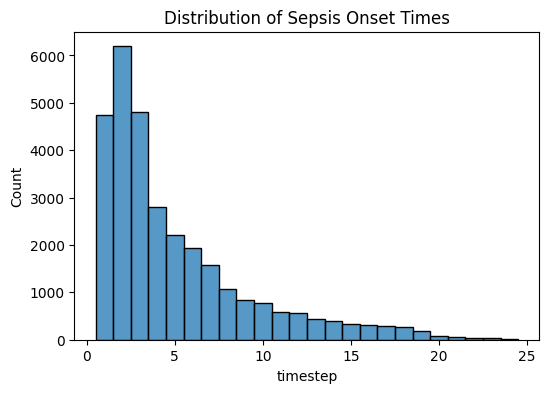

In [5]:
onset_times = data[data["sepsis"] == 1].index.get_level_values("timestep")
plt.figure(figsize=(6, 4))
sns.histplot(onset_times, discrete=True)
plt.title("Distribution of Sepsis Onset Times")
plt.show()

# Static Feautres

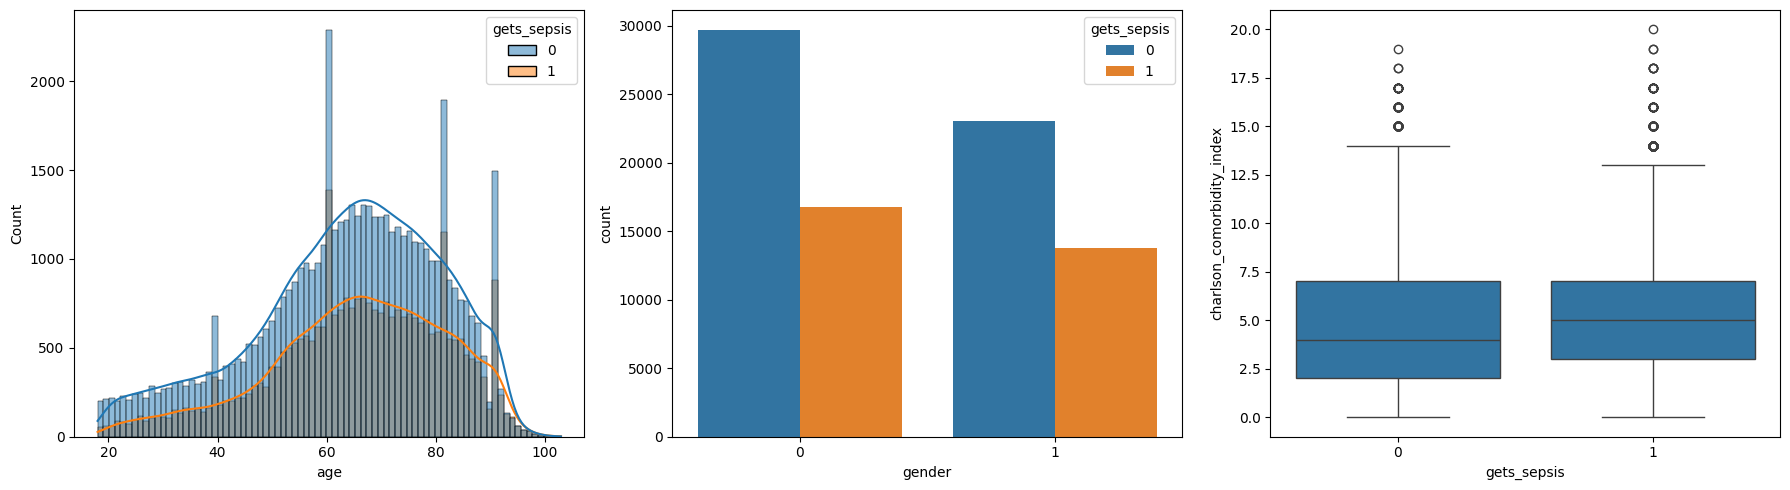

In [6]:
# Extract one row per patient for static vars
static_data = data.groupby(level="stay_id")[
    ["age", "gender", "charlson_comorbidity_index", "gets_sepsis"]
].first()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=static_data, x="age", hue="gets_sepsis", kde=True, ax=ax[0])
sns.countplot(data=static_data, x="gender", hue="gets_sepsis", ax=ax[1])
sns.boxplot(data=static_data, x="gets_sepsis", y="charlson_comorbidity_index", ax=ax[2])
plt.tight_layout()
plt.show()

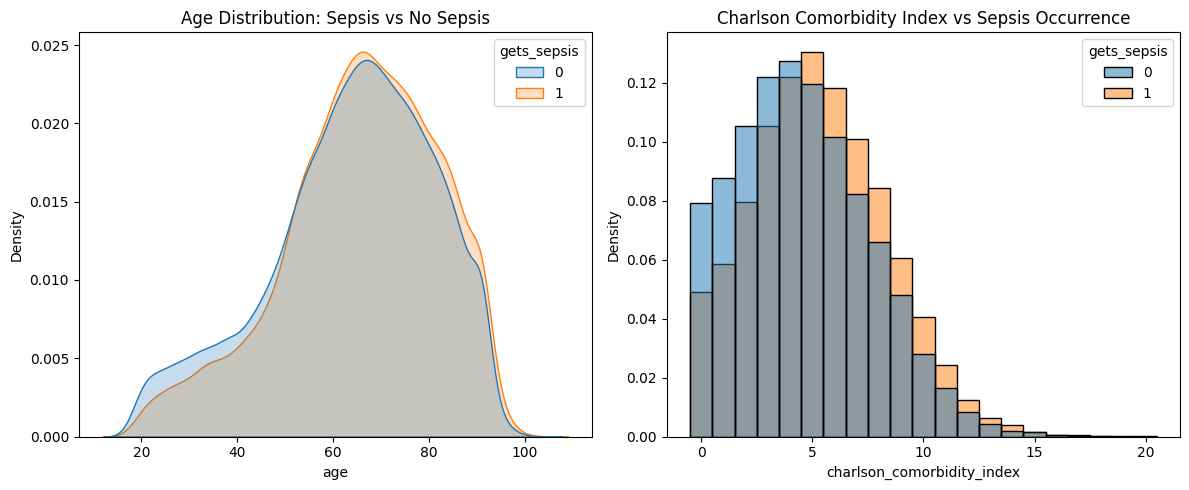

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(
    data=static_data, x="age", hue="gets_sepsis", common_norm=False, fill=True, ax=ax[0]
)
ax[0].set_title("Age Distribution: Sepsis vs No Sepsis")

# Comorbidity distribution
sns.histplot(
    data=static_data,
    x="charlson_comorbidity_index",
    hue="gets_sepsis",
    alpha=0.5,
    discrete=True,
    stat="density",
    common_norm=False,
    ax=ax[1],
)
ax[1].set_title("Charlson Comorbidity Index vs Sepsis Occurrence")

plt.tight_layout()
plt.show()

# Non-Static Features

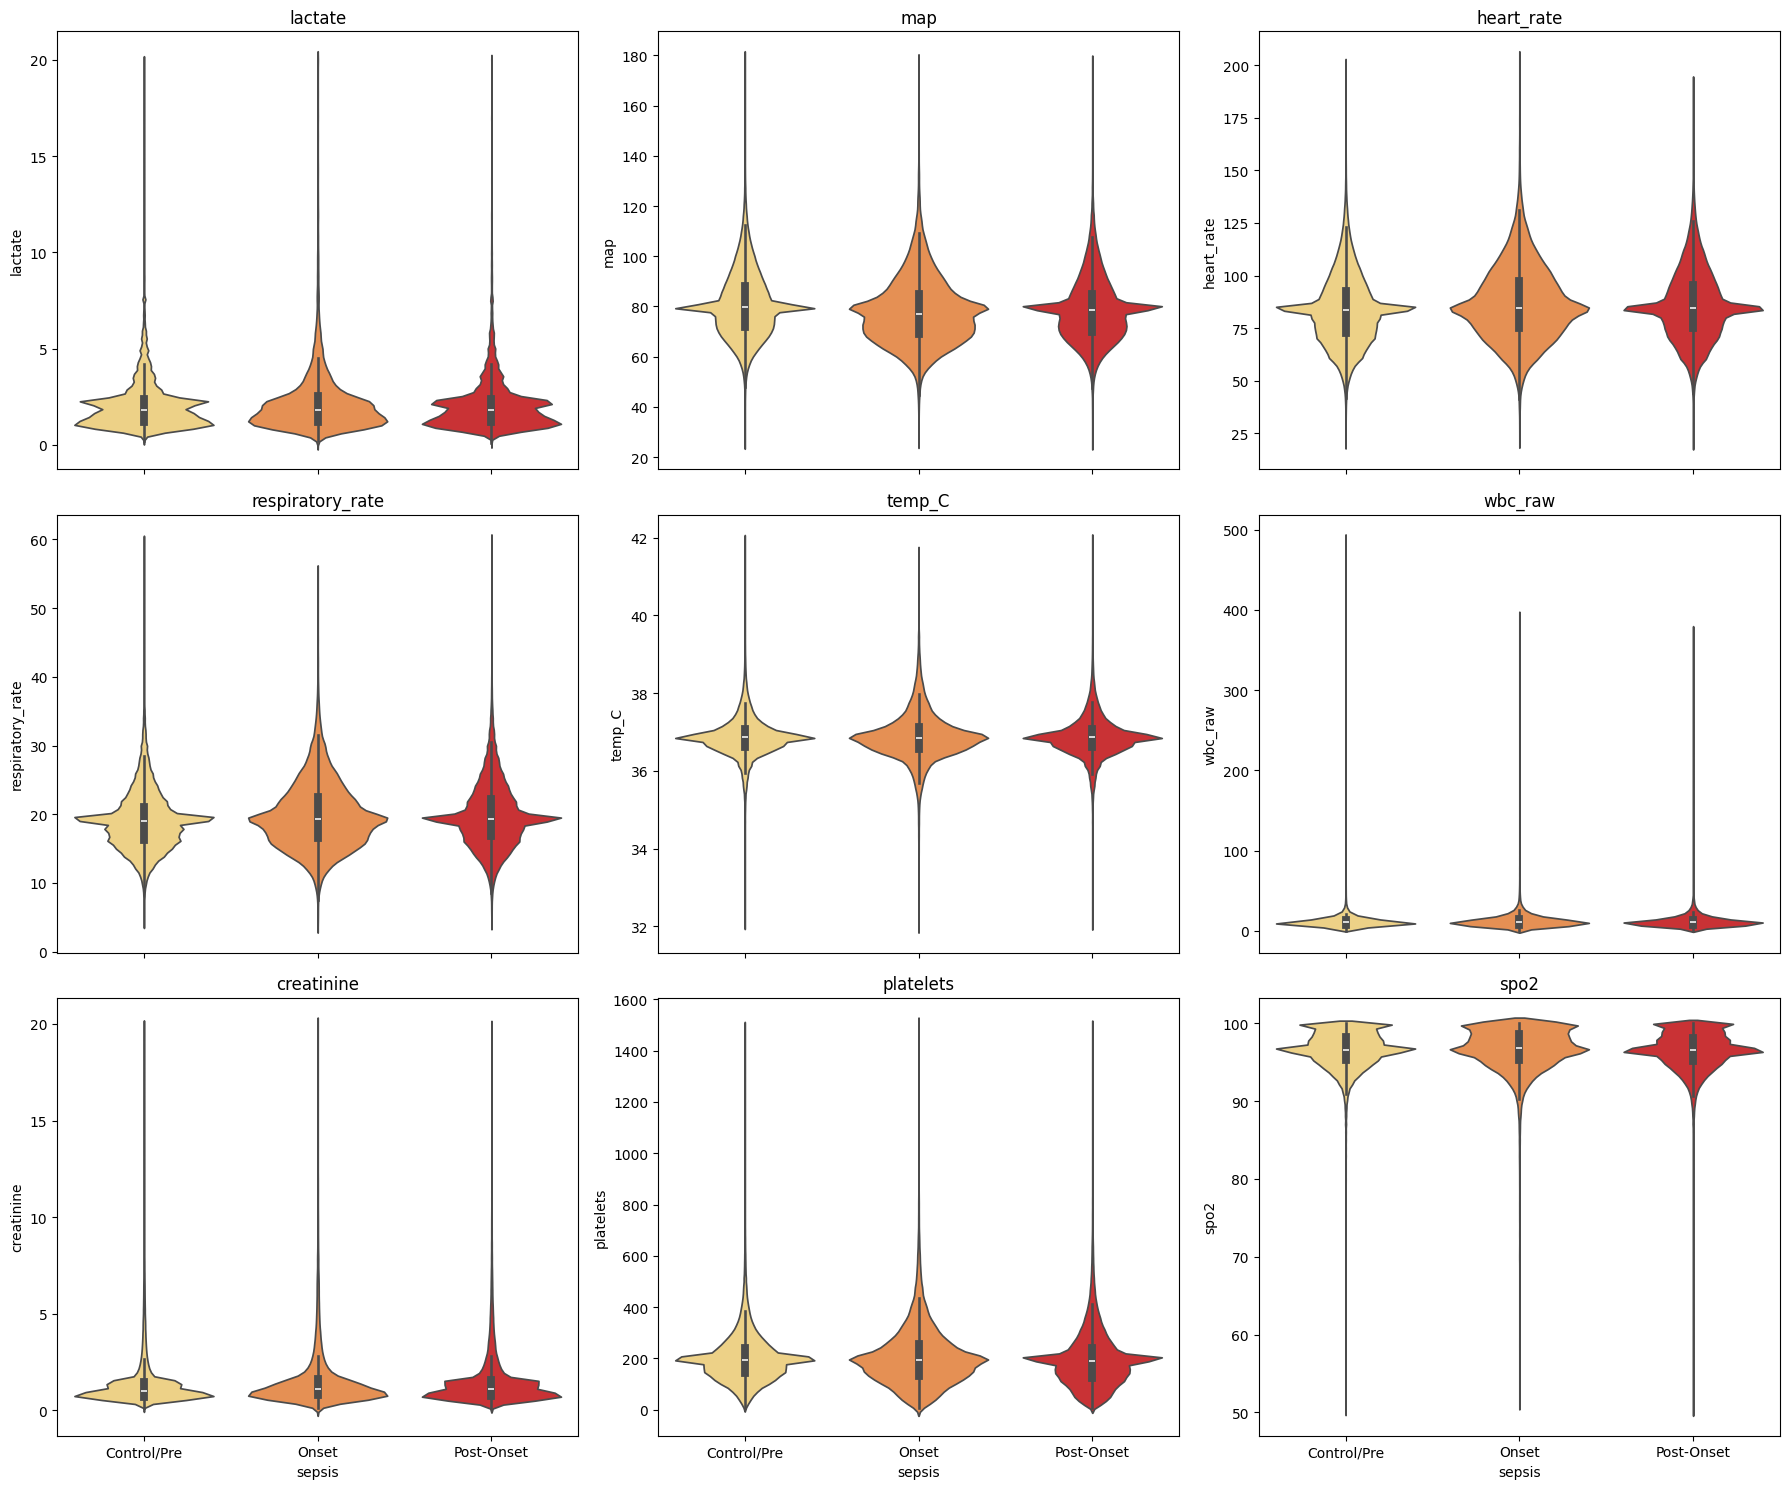

In [8]:
plot_data = data.reset_index().copy()

# reverse the log1p transform
plot_data["wbc_raw"] = np.expm1(plot_data["wbc_log1p"])

fig, ax = plt.subplots(3, 3, figsize=(18, 15), sharex=True)
ax = ax.flatten()

features = [
    "lactate",
    "map",
    "heart_rate",
    "respiratory_rate",
    "temp_C",
    "wbc_raw",
    "creatinine",
    "platelets",
    "spo2",
]

plot_data.replace(
    {"sepsis": {0: "Control/Pre", 1: "Onset", 2: "Post-Onset"}}, inplace=True
)

for i, col in enumerate(features):
    sns.violinplot(
        x="sepsis", y=col, data=plot_data, ax=ax[i], palette="YlOrRd", hue="sepsis"
    )
    ax[i].set_title(col)

# delete plot_data to free memory
del plot_data

plt.tight_layout()
plt.show()

# Time Series Plots

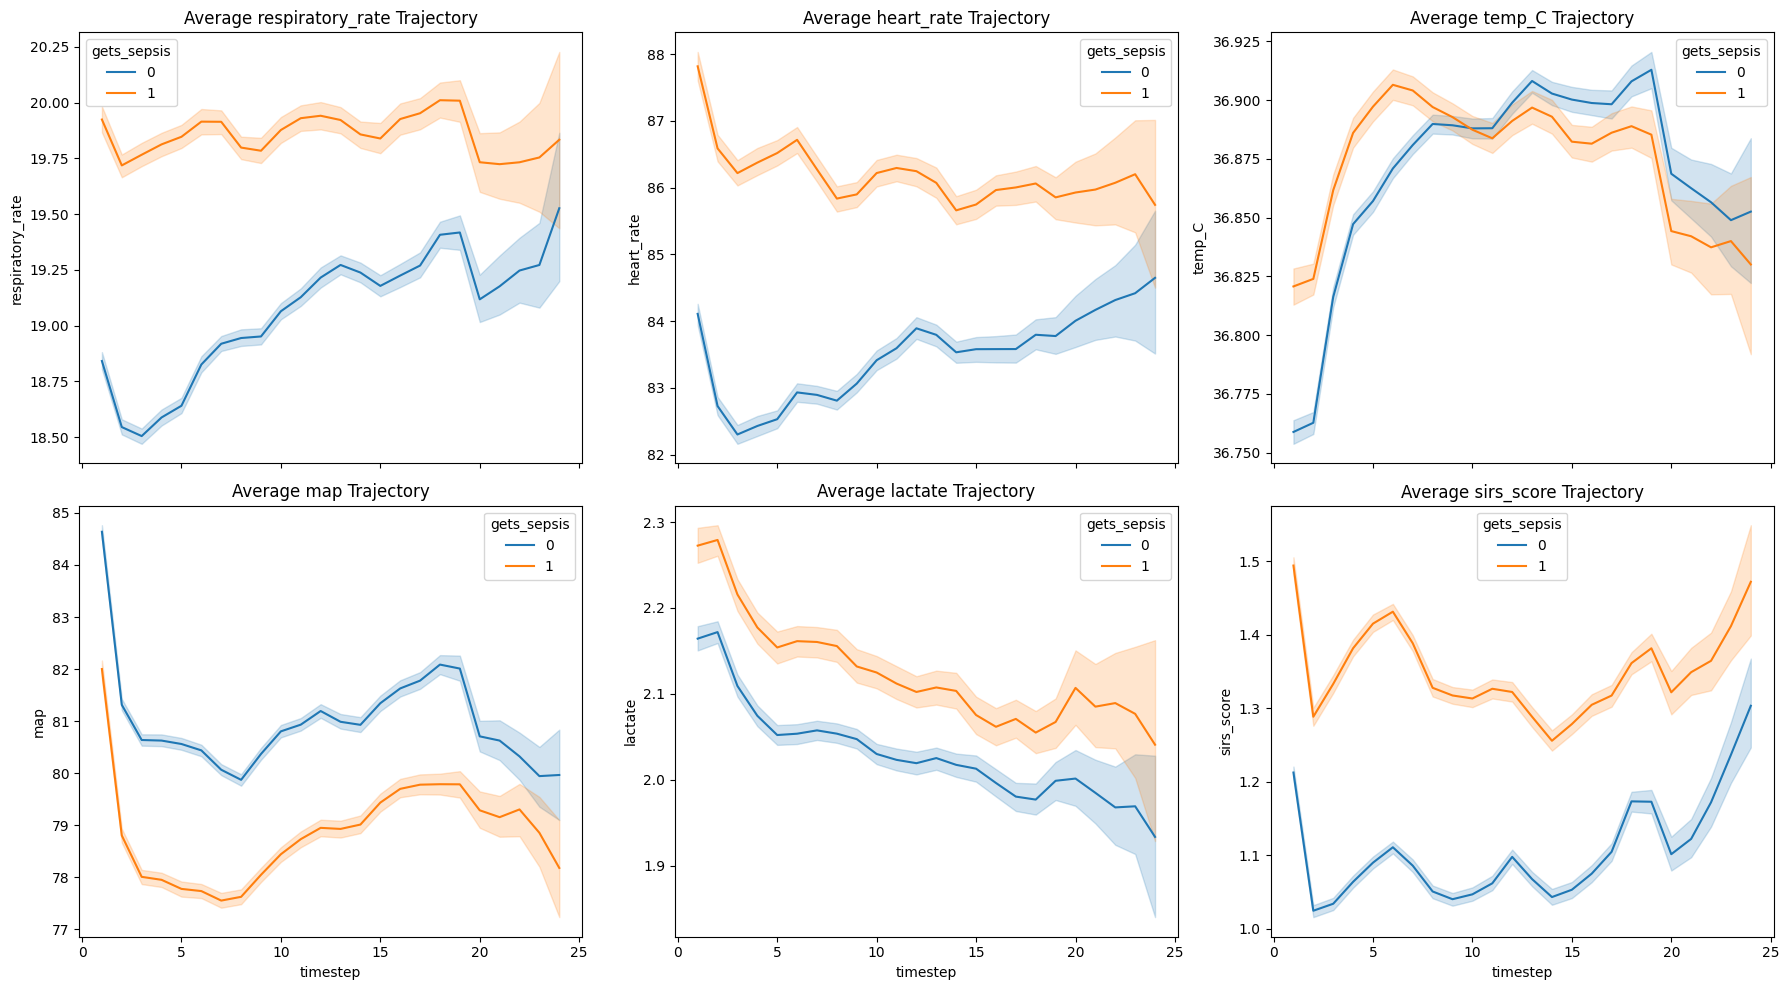

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

# select highly dynamic, frequently updated features that capture early signs of shock.
# Vitals like respiratory rate and heart rate respond rapidly to infection,
# while map, lactate, and sirs_score indicate the progression into septic shock.
# Routine labs (e.g., creatinine, wbc) are excluded as their low sampling frequency creates blocky, imputed trajectories.
features_to_plot = [
    "respiratory_rate",
    "heart_rate",
    "temp_C",
    "map",
    "lactate",
    "sirs_score",
]

for i, col in enumerate(features_to_plot):
    sns.lineplot(
        data=data.reset_index(),
        x="timestep",
        y=col,
        hue="gets_sepsis",
        ax=ax.flatten()[i],
    )
    ax.flatten()[i].set_title(f"Average {col} Trajectory")

plt.tight_layout()
plt.show()

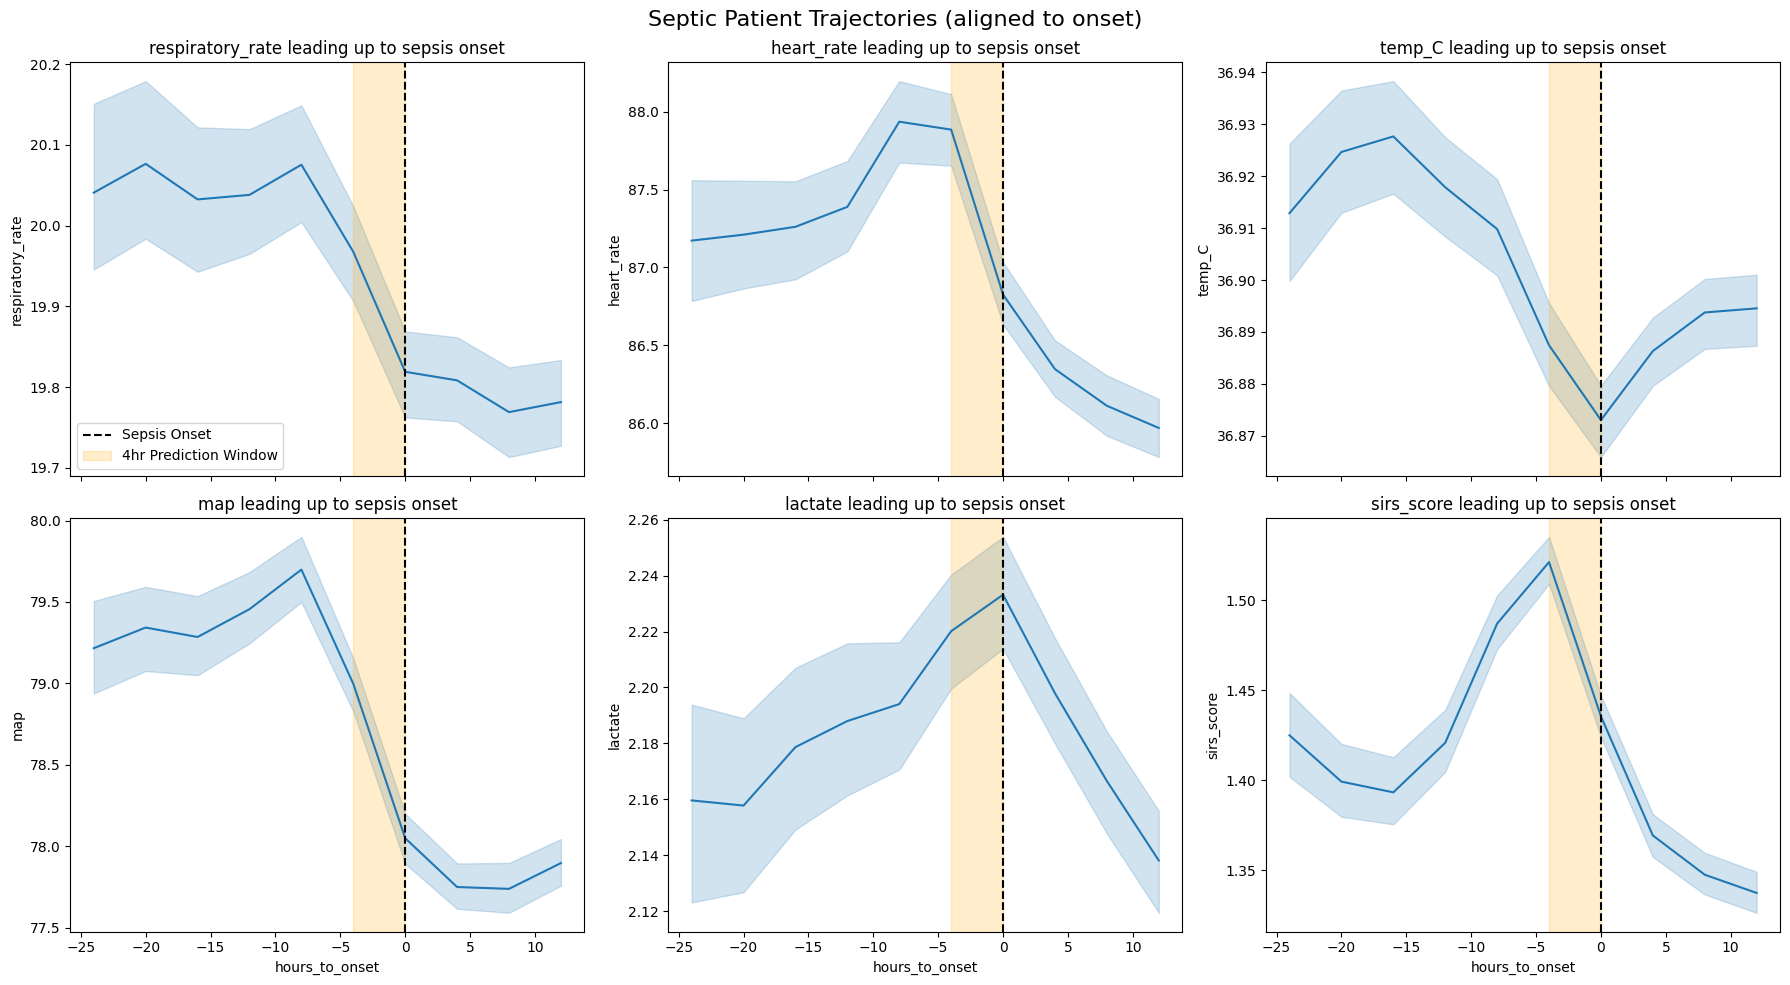

In [10]:
septic_df = data[data["gets_sepsis"] == 1].reset_index()

# find exact timestep where sepsis=1 first occurs for each patient
onset_times = (
    septic_df[septic_df["sepsis"] == 1]
    .groupby("stay_id")["timestep"]
    .min()
    .reset_index()
)
onset_times.columns = ["stay_id", "onset_timestep"]

# merge back and calculate 'time_to_onset' (negative values = before onset)
aligned_df = septic_df.merge(onset_times, on="stay_id")
aligned_df["hours_to_onset"] = (
    aligned_df["timestep"] - aligned_df["onset_timestep"]
) * 4

window_df = aligned_df[
    (aligned_df["hours_to_onset"] >= -24) & (aligned_df["hours_to_onset"] <= 12)
]

# plot
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
features = ["respiratory_rate", "heart_rate", "temp_C", "map", "lactate", "sirs_score"]
ax = ax.flatten()
for i, col in enumerate(features):
    sns.lineplot(data=window_df, x="hours_to_onset", y=col, ax=ax[i])
    ax[i].axvline(0, color="black", linestyle="--", label="Sepsis Onset")
    ax[i].axvspan(-4, 0, alpha=0.2, label="4hr Prediction Window", color="orange")
    ax[i].set_title(f"{col} leading up to sepsis onset")
    if i == 0:
        ax[i].legend()

plt.suptitle("Septic Patient Trajectories (aligned to onset)", fontsize=16)
plt.tight_layout()
plt.show()

# Correlation Heatmap

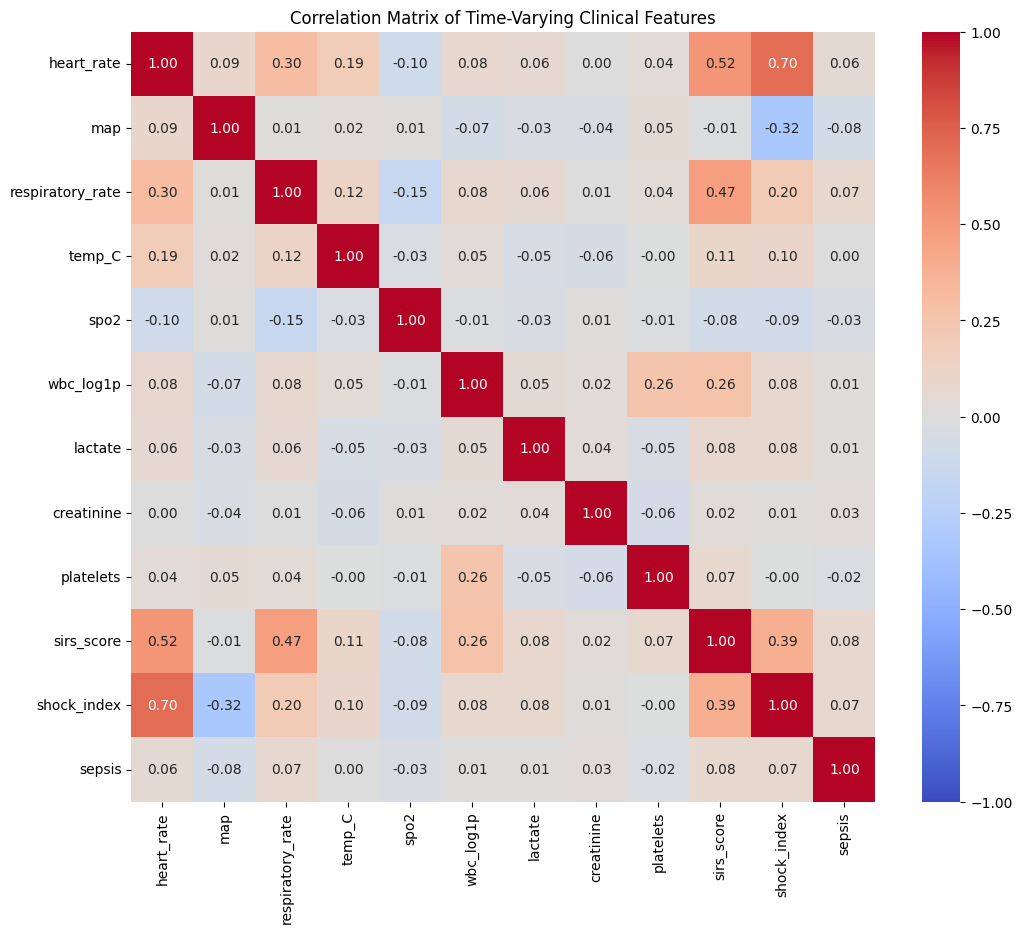

In [11]:
plt.figure(figsize=(12, 10))
# non-numeric/ static columns dropped for the time-series correlation
cols_to_corr = [
    "heart_rate",
    "map",
    "respiratory_rate",
    "temp_C",
    "spo2",
    "wbc_log1p",
    "lactate",
    "creatinine",
    "platelets",
    "sirs_score",
    "shock_index",
    "sepsis",
]

corr = data[cols_to_corr].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Time-Varying Clinical Features")
plt.show()